In [3]:
import matplotlib as mpl
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from morris_lecar.plot_styles import set_thesis_style

set_thesis_style()

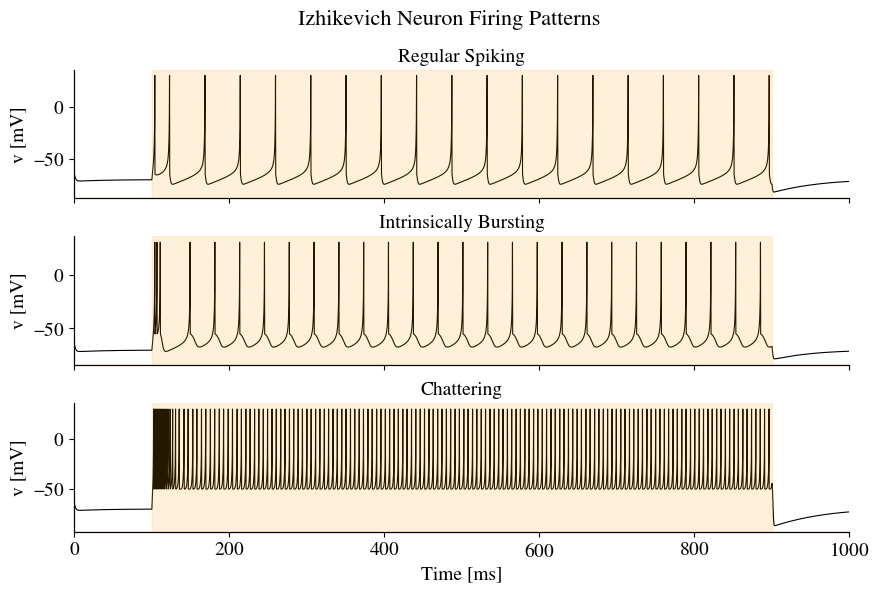

In [10]:
import numpy as np

import matplotlib.pyplot as plt

def simulate_izhikevich(params, T=1000.0, dt=0.25, I_in=None, v_init=None, u_init=None):
    """
    Simulate Izhikevich neuron.
    params: dict with keys 'a','b','c','d'
    T: total time (ms)
    dt: time step (ms)
    I_in: input current array (length N) or scalar (constant current)
    v_init, u_init: optional initial conditions
    Returns t, v, u, spikes (indices)
    """
    a, b, c, d = params['a'], params['b'], params['c'], params['d']
    t = np.arange(0, T+dt, dt)
    N = len(t)
    if np.isscalar(I_in) or I_in is None:
        I = np.full(N, 0.0 if I_in is None else float(I_in))
    else:
        I = np.asarray(I_in, dtype=float)
        if I.shape[0] != N:
            raise ValueError("I_in length must match time array length")
    # initial conditions
    v = np.full(N, -65.0 if v_init is None else float(v_init))
    u = np.full(N, b * v[0] if u_init is None else float(u_init))
    spikes = []
    for i in range(N-1):
        dv = (0.04 * v[i]**2 + 5 * v[i] + 140 - u[i] + I[i]) * dt
        du = (a * (b * v[i] - u[i])) * dt
        v[i+1] = v[i] + dv
        u[i+1] = u[i] + du
        if v[i+1] >= 30.0:
            v[i] = 30.0  # mark spike peak
            v[i+1] = c
            u[i+1] = u[i+1] + d
            spikes.append(i)
    return t, v, u, np.array(spikes)

# Parameter sets for different firing patterns (from Izhikevich 2003)
izhikevich_sets = {
    'Regular Spiking': {'a': 0.02, 'b': 0.2, 'c': -65.0, 'd': 8.0},
    'Intrinsically Bursting': {'a': 0.02, 'b': 0.2, 'c': -55.0, 'd': 4.0},
    'Chattering': {'a': 0.02, 'b': 0.2, 'c': -50.0, 'd': 2.0},
}

# Common simulation parameters
T = 1000.0  # ms
dt = 0.25
t = np.arange(0, T+dt, dt)

# Define input currents for each type (step currents that start at 100ms and end at 900ms)
I_base = np.zeros_like(t)
I_base[(t >= 100) & (t <= 900)] = 10.0  # moderate step
I_RS = I_base.copy()                      # regular spiking with moderate current
I_IB = I_base.copy()                      # bursting often evoked by similar input
I_CH = np.zeros_like(t)
I_CH[(t >= 100) & (t <= 900)] = 20.0      # chattering often needs stronger drive

inputs = {
    'Regular Spiking': I_RS,
    'Intrinsically Bursting': I_IB,
    'Chattering': I_CH,
}

# Run simulations and plot results
fig, axes = plt.subplots(len(izhikevich_sets), 1, figsize=(10, 6), sharex=True, gridspec_kw={'hspace': 0.3})
if len(izhikevich_sets) == 1:
    axes = [axes]

for ax, (name, params) in zip(axes, izhikevich_sets.items()):
    I = inputs[name]
    tt, v, u, spikes = simulate_izhikevich(params, T=T, dt=dt, I_in=I)
    ax.plot(tt, v, color='black', lw=0.8)
    ax.set_ylabel('v [mV]')
    ax.set_title(f"{name}")
    # show input as a light filled area on same axis (scaled)
    ax_twin = ax.twinx()
    ax_twin.fill_between(tt, 0, I/np.max(I+1e-9)*30, color='orange', alpha=0.15)
    ax_twin.set_ylim(0, 30)
    ax_twin.set_yticks([])
    ax.set_xlim(0, T)
    ax.grid(False)

axes[-1].set_xlabel('Time [ms]')
fig.suptitle("Izhikevich Neuron Firing Patterns", fontsize=16)
# plt.tight_layout()
plt.savefig("izhikevich_spike_patterns.pdf", bbox_inches='tight')
plt.show()